In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

In [3]:
path = Path("../data/es_dollar_bars.csv")

if not path.exists():
    raise FileNotFoundError("data/es_dollar_bars.csv not found.")

bars = pd.read_csv(path, parse_dates=["timestamp"])
bars = bars.sort_values("timestamp").reset_index(drop=True)

close = bars.set_index("timestamp")["close"].sort_index()

print("Start:", close.index.min())
print("End:", close.index.max())
print("Bars:", len(close))

Start: 2013-09-01 17:19:56.232000
End: 2013-09-03 13:49:06.359000
Bars: 149


In [4]:
FAST = 10
SLOW = 30

features = pd.DataFrame(index=close.index)
features["close"] = close
features["ma_fast"] = close.rolling(FAST).mean()
features["ma_slow"] = close.rolling(SLOW).mean()

features["side"] = np.where(
    features["ma_fast"] > features["ma_slow"],
    1,
    -1
)

features = features.dropna()

display(features.head())

,close,ma_fast,ma_slow,side
timestamp,,,,
2013-09-03 06:05:33.739,1645.25,1644.875,1645.225000,-1
2013-09-03 06:32:56.811,1643.75,1644.450,1645.333333,-1
2013-09-03 07:01:45.896,1645.00,1644.175,1645.475000,-1
2013-09-03 07:26:58.974,1644.75,1644.300,1645.550000,-1
2013-09-03 07:49:37.527,1646.50,1644.600,1645.666667,-1


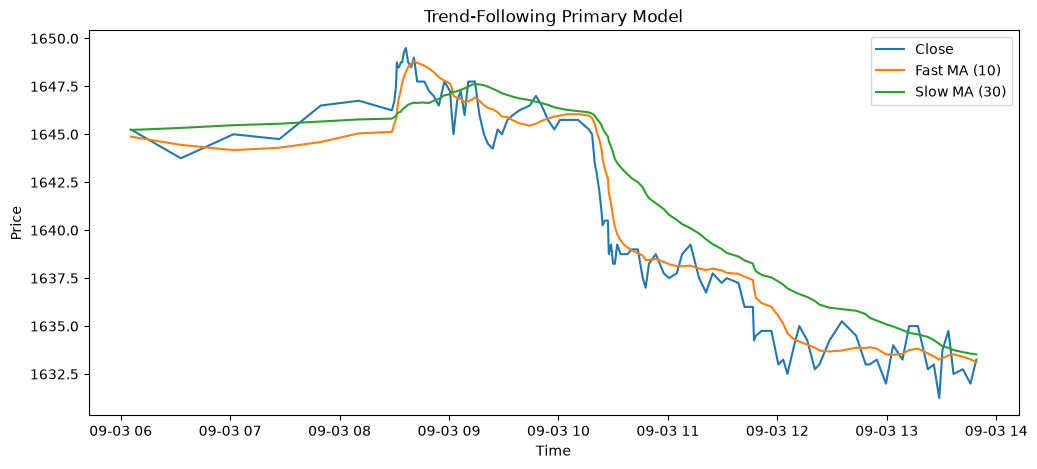

In [5]:
plt.figure(figsize=(12,5))
plt.plot(features.index, features["close"], label="Close")
plt.plot(features.index, features["ma_fast"], label=f"Fast MA ({FAST})")
plt.plot(features.index, features["ma_slow"], label=f"Slow MA ({SLOW})")
plt.title("Trend-Following Primary Model")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [6]:
def get_daily_vol(close, span=100):
    idx = close.index.searchsorted(close.index - pd.Timedelta(days=1))
    idx = idx[idx > 0]

    prev_idx = pd.Series(
        close.index[idx - 1],
        index=close.index[close.shape[0] - idx.shape[0]:]
    )

    daily_ret = (
        close.loc[prev_idx.index].values /
        close.loc[prev_idx.values].values - 1
    )

    daily_ret = pd.Series(daily_ret, index=prev_idx.index)

    return daily_ret.ewm(span=span).std()

daily_vol = get_daily_vol(close)

In [7]:
def cusum_filter(close, threshold):
    log_ret = np.log(close).diff().dropna()
    s_pos, s_neg = 0.0, 0.0
    events = []

    for t in log_ret.index:
        if t not in threshold.index:
            continue

        h = threshold.loc[t]
        if pd.isna(h) or h <= 0:
            continue

        x = log_ret.loc[t]
        s_pos = max(0.0, s_pos + x)
        s_neg = min(0.0, s_neg + x)

        if s_neg < -h:
            s_neg = 0.0
            events.append(t)
        elif s_pos > h:
            s_pos = 0.0
            events.append(t)

    return pd.DatetimeIndex(events)

threshold = daily_vol.reindex(close.index, method="ffill")
t_events = cusum_filter(close, threshold)

print("CUSUM events:", len(t_events))

CUSUM events: 13


In [19]:
def add_vertical_barrier(t_events, close, num_hours=1):
    positions = close.index.searchsorted(
        t_events + pd.Timedelta(hours=num_hours)
    )

    valid = positions < len(close)
    positions = positions[valid]
    valid_events = t_events[valid]

    return pd.Series(close.index[positions], index=valid_events)

t1 = add_vertical_barrier(t_events, close, num_hours=1)

print("Valid vertical barriers:", len(t1))

Valid vertical barriers: 13


In [20]:
trgt = daily_vol.reindex(t_events, method="ffill").dropna()
side = features["side"].reindex(t_events, method="ffill").dropna()

common_events = (
    trgt.index
        .intersection(t1.index)
        .intersection(side.index)
)

trgt = trgt.loc[common_events]
t1 = t1.loc[common_events]
side = side.loc[common_events]

print("Usable events:", len(common_events))

Usable events: 11


In [21]:
def apply_triple_barrier_meta(close, t_events, t1, trgt, side, pt_sl=(1,2)):
    records = []

    for t0 in t_events:
        end = t1.loc[t0]
        target = trgt.loc[t0]
        trade_side = side.loc[t0]

        path = close.loc[t0:end]

        if len(path) < 2:
            continue

        raw_ret = path / path.iloc[0] - 1
        side_ret = raw_ret * trade_side

        pt_touch = pd.NaT
        sl_touch = pd.NaT

        if pt_sl[0] > 0:
            hit = side_ret[side_ret > pt_sl[0] * target]
            if not hit.empty:
                pt_touch = hit.index[0]

        if pt_sl[1] > 0:
            hit = side_ret[side_ret < -pt_sl[1] * target]
            if not hit.empty:
                sl_touch = hit.index[0]

        candidates = [end]
        if pd.notna(pt_touch):
            candidates.append(pt_touch)
        if pd.notna(sl_touch):
            candidates.append(sl_touch)

        first_touch = min(candidates)

        if pd.notna(pt_touch) and first_touch == pt_touch:
            barrier = "pt"
        elif pd.notna(sl_touch) and first_touch == sl_touch:
            barrier = "sl"
        else:
            barrier = "vertical"

        records.append({
            "t0": t0,
            "t1": first_touch,
            "trgt": target,
            "side": trade_side,
            "first_barrier": barrier
        })

    columns = ["t0", "t1", "trgt", "side", "first_barrier"]
    return pd.DataFrame(records, columns=columns).set_index("t0")

events = apply_triple_barrier_meta(
    close=close,
    t_events=common_events,
    t1=t1,
    trgt=trgt,
    side=side,
    pt_sl=(1,2)
)

print("Events:", len(events))
display(events.head())
display(events["first_barrier"].value_counts())

Events: 11


,t1,trgt,side,first_barrier
t0,,,,
2013-09-03 07:49:37.527,2013-09-03 08:51:34.336,0.001877,-1.0,vertical
2013-09-03 08:34:19.184,2013-09-03 09:35:00.689,0.001505,1.0,vertical
2013-09-03 08:51:34.336,2013-09-03 09:54:15.160,0.001464,1.0,vertical
2013-09-03 09:02:26.499,2013-09-03 10:04:34.458,0.001358,-1.0,vertical
2013-09-03 09:06:21.906,2013-09-03 09:19:07.718,0.001317,-1.0,pt


first_barrier
vertical    7
pt          4
Name: count, dtype: int64

In [22]:
def get_meta_labels(events, close):
    out = pd.DataFrame(index=events.index)

    raw_ret = pd.Series(
        [
            close.loc[row["t1"]] / close.loc[t0] - 1
            for t0, row in events.iterrows()
        ],
        index=events.index
    )

    out["ret"] = raw_ret * events["side"]
    out["bin"] = (out["ret"] > 0).astype(int)

    return out

meta_labels = get_meta_labels(events, close)
events = events.join(meta_labels)

display(events.head())
display(events["bin"].value_counts().sort_index())

,t1,trgt,side,first_barrier,ret,bin
t0,,,,,,
2013-09-03 07:49:37.527,2013-09-03 08:51:34.336,0.001877,-1.0,vertical,-0.000304,0
2013-09-03 08:34:19.184,2013-09-03 09:35:00.689,0.001505,1.0,vertical,-0.001668,0
2013-09-03 08:51:34.336,2013-09-03 09:54:15.160,0.001464,1.0,vertical,-0.000759,0
2013-09-03 09:02:26.499,2013-09-03 10:04:34.458,0.001358,-1.0,vertical,-0.000456,0
2013-09-03 09:06:21.906,2013-09-03 09:19:07.718,0.001317,-1.0,pt,0.001366,1


bin
0    4
1    7
Name: count, dtype: int64

In [23]:
feature_frame = pd.DataFrame(index=close.index)

feature_frame["ma_fast"] = close.rolling(FAST).mean()
feature_frame["ma_slow"] = close.rolling(SLOW).mean()

feature_frame["ma_distance"] = (
    feature_frame["ma_fast"] /
    feature_frame["ma_slow"] - 1
)

feature_frame["return_5"] = close.pct_change(5)

feature_frame["vol_10"] = (
    np.log(close).diff().rolling(10).std()
)

feature_frame["side"] = features["side"]

feature_frame = feature_frame.reindex(events.index)
feature_frame["target_vol"] = events["trgt"]

dataset = feature_frame.join(
    events["bin"].rename("label")
).dropna()

display(dataset.head())
print("Dataset size:", len(dataset))

,ma_fast,ma_slow,ma_distance,return_5,vol_10,side,target_vol,label
t0,,,,,,,,
2013-09-03 07:49:37.527,1644.60,1645.666667,-0.000648,0.000608,0.001177,-1.0,0.001877,0
2013-09-03 08:34:19.184,1647.70,1646.283333,0.000861,0.000759,0.000419,1.0,0.001505,0
2013-09-03 08:51:34.336,1648.25,1646.750000,0.000911,-0.001213,0.000336,1.0,0.001464,0
2013-09-03 09:02:26.499,1647.00,1647.208333,-0.000126,-0.001214,0.000448,-1.0,0.001358,0
2013-09-03 09:06:21.906,1646.85,1647.316667,-0.000283,-0.000303,0.000581,-1.0,0.001317,1


Dataset size: 11


In [24]:
feature_cols = [
    "ma_distance",
    "return_5",
    "vol_10",
    "target_vol",
    "side"
]

split = int(len(dataset) * 0.70)

train = dataset.iloc[:split]
test = dataset.iloc[split:]

X_train = train[feature_cols]
y_train = train["label"]

X_test = test[feature_cols]
y_test = test["label"]

print("Train observations:", len(train))
print("Test observations:", len(test))
print()
print("Train labels:")
print(y_train.value_counts())
print()
print("Test labels:")
print(y_test.value_counts())

Train observations: 7
Test observations: 4

Train labels:
label
0    4
1    3
Name: count, dtype: int64

Test labels:
label
1    4
Name: count, dtype: int64


In [25]:
if len(dataset) < 10 or len(train) == 0 or y_train.nunique() < 2:
    print(
        "Not enough observations/classes to train a meaningful Random Forest. "
        "A longer dataset is required."
    )
    model = None
else:
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=3,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_train, y_train)
    print("Random Forest trained.")

Random Forest trained.


In [26]:
if model is not None and len(X_test) > 0:
    pred = model.predict(X_test)

    print(f"Accuracy:  {accuracy_score(y_test, pred):.3f}")
    print(f"Precision: {precision_score(y_test, pred, zero_division=0):.3f}")
    print(f"Recall:    {recall_score(y_test, pred, zero_division=0):.3f}")
    print(f"F1 Score:  {f1_score(y_test, pred, zero_division=0):.3f}")
    print()
    print(classification_report(y_test, pred, zero_division=0))
else:
    print("Model evaluation skipped.")

Accuracy:  0.500
Precision: 1.000
Recall:    0.500
F1 Score:  0.667

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.50      0.67         4

    accuracy                           0.50         4
   macro avg       0.50      0.25      0.33         4
weighted avg       1.00      0.50      0.67         4



In [27]:
if model is not None and len(X_test) > 0:
    cm = confusion_matrix(y_test, pred, labels=[0,1])

    cm_df = pd.DataFrame(
        cm,
        index=["Actual Pass", "Actual Trade"],
        columns=["Predicted Pass", "Predicted Trade"]
    )

    display(cm_df)

,Predicted Pass,Predicted Trade
Actual Pass,0,0
Actual Trade,2,2


target_vol     0.434783
vol_10         0.304348
ma_distance    0.130435
return_5       0.130435
side           0.000000
dtype: float64

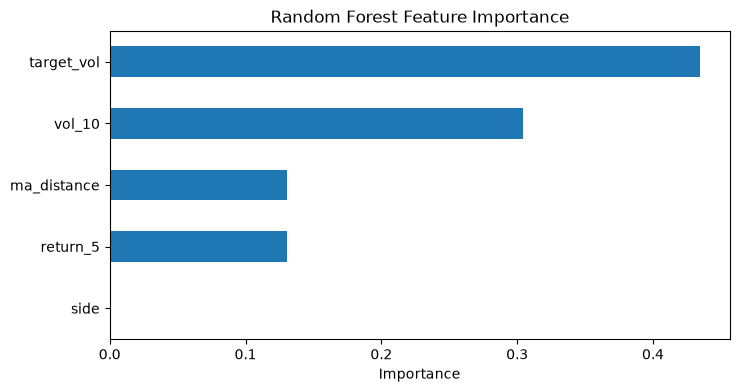

In [28]:
if model is not None:
    importance = pd.Series(
        model.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)

    display(importance)

    plt.figure(figsize=(8,4))
    importance.sort_values().plot(kind="barh")
    plt.title("Random Forest Feature Importance")
    plt.xlabel("Importance")
    plt.show()